# MATPMD4 Assignment 1 – Stochastic Processes
**Student ID:** 3446707  
**Lecturer:** Anthony O'Hare

In [1]:
!pip install numpy scipy matplotlib

error: externally-managed-environment

× This environment is externally managed
╰─> To install Python packages system-wide, try apt install
    python3-xyz, where xyz is the package you are trying to
    install.
    
    If you wish to install a non-Debian-packaged Python package,
    create a virtual environment using python3 -m venv path/to/venv.
    Then use path/to/venv/bin/python and path/to/venv/bin/pip. Make
    sure you have python3-full installed.
    
    If you wish to install a non-Debian packaged Python application,
    it may be easiest to use pipx install xyz, which will manage a
    virtual environment for you. Make sure you have pipx installed.
    
    See /usr/share/doc/python3.12/README.venv for more information.

note: If you believe this is a mistake, please contact your Python installation or OS distribution provider. You can override this, at the risk of breaking your Python installation or OS, by passing --break-system-packages.
hint: See PEP 668 for the detai

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

np.random.seed(3446707)

---
## Question 1

Yes, I have read and understood the instructions on the cover page.

---
## Question 2 – Absorbing Markov Chains

The transition matrix over states A, B, C, D, E is:

$$P = \begin{pmatrix} 0.21 & 0.07 & 0.15 & 0.11 & 0.46 \\ 0 & 1 & 0 & 0 & 0 \\ 0.16 & 0.16 & 0.22 & x & 0.26 \\ 0 & 0 & 0 & 1 & 0 \\ 0.21 & 0.27 & 0.18 & 0.24 & 0.10 \end{pmatrix}$$

### (a) Finding x

A **stochastic matrix** requires every row to sum to exactly 1. This is because each row gives the probability distribution over all possible next states from the current state — these are mutually exclusive, exhaustive outcomes, so by the total probability axiom they must sum to 1.

For row C (row index 2):
$$0.16 + 0.16 + 0.22 + x + 0.26 = 1 \implies x = 1 - 0.80 = 0.20$$

In [3]:
x_val = 1 - (0.16 + 0.16 + 0.22 + 0.26)
print(f"x = {x_val:.4f}")

P = np.array([
    [0.21, 0.07, 0.15, 0.11,   0.46],
    [0.00, 1.00, 0.00, 0.00,   0.00],
    [0.16, 0.16, 0.22, x_val,  0.26],
    [0.00, 0.00, 0.00, 1.00,   0.00],
    [0.21, 0.27, 0.18, 0.24,   0.10]
])

print("Row sums (must all equal 1.0):")
print(P.sum(axis=1))

x = 0.2000
Row sums (must all equal 1.0):
[1. 1. 1. 1. 1.]


### (b) Distribution after 3 generations

The distribution after $n$ steps is $\pi^{(n)} = \pi^{(0)} P^n$, computed iteratively as $\pi^{(n+1)} = \pi^{(n)} P$.

In [4]:
pi0 = np.array([0.13, 0.24, 0.32, 0.28, 0.03])
pi1 = pi0 @ P
pi2 = pi1 @ P
pi3 = pi2 @ P

labels = ['A', 'B', 'C', 'D', 'E']
for n, pi in enumerate([pi0, pi1, pi2, pi3]):
    row = "  ".join(f"{l}={v:.6f}" for l, v in zip(labels, pi))
    print(f"pi{n}: {row}")

pi0: A=0.130000  B=0.240000  C=0.320000  D=0.280000  E=0.030000
pi1: A=0.084800  B=0.308400  C=0.095300  D=0.365500  E=0.146000
pi2: A=0.063716  B=0.369004  C=0.059966  D=0.428928  E=0.078386
pi3: A=0.039436  B=0.404223  C=0.036859  D=0.466743  E=0.052739


From the results above we can see that the probability in the transient states A, C, and E drops with each generation, while it builds up in the absorbing states B and D. This makes sense — once the chain enters B or D it can't leave, so probability keeps flowing in and never comes back out. State E loses probability particularly quickly since it has a relatively high chance (0.27) of jumping straight into B. Given enough time, all probability will end up in B or D.

### (c) Canonical form

The **absorbing states** are B and D (rows with a single 1 on the diagonal). The **transient states** are A, C, E.

The canonical ordering places transient states first: **A, C, E, B, D** (original indices 0, 2, 4, 1, 3).

$$P_{\text{can}} = \begin{pmatrix} Q & R \\ \mathbf{0} & I \end{pmatrix}$$

where $Q$ (3x3) contains transient-to-transient probabilities and $R$ (3x2) contains transient-to-absorbing probabilities.

In [5]:
idx = [0, 2, 4, 1, 3]  # A, C, E, B, D
Pc = P[np.ix_(idx, idx)]

print("Canonical P (order: A, C, E, B, D):")
print(np.round(Pc, 4))

Q = Pc[:3, :3]   # transient -> transient
R = Pc[:3, 3:]   # transient -> absorbing

print("\nQ (transient to transient, states A, C, E):")
print(np.round(Q, 4))
print("\nR (transient to absorbing, states A,C,E -> B,D):")
print(np.round(R, 4))

Canonical P (order: A, C, E, B, D):
[[0.21 0.15 0.46 0.07 0.11]
 [0.16 0.22 0.26 0.16 0.2 ]
 [0.21 0.18 0.1  0.27 0.24]
 [0.   0.   0.   1.   0.  ]
 [0.   0.   0.   0.   1.  ]]

Q (transient to transient, states A, C, E):
[[0.21 0.15 0.46]
 [0.16 0.22 0.26]
 [0.21 0.18 0.1 ]]

R (transient to absorbing, states A,C,E -> B,D):
[[0.07 0.11]
 [0.16 0.2 ]
 [0.27 0.24]]


### (d) Mean number of visits to each transient state

The **fundamental matrix** $N = (I - Q)^{-1}$ gives us what we need here. Each entry $N_{ij}$ tells us the expected number of times the process visits transient state $j$, given it started in transient state $i$.

To understand why: starting from state $i$, the expected visits to state $j$ over all time steps is $\sum_{n=0}^{\infty}(Q^n)_{ij}$. Since the chain always gets absorbed eventually, all eigenvalues of $Q$ are less than 1 in modulus, so this sum converges — and it converges to $(I-Q)^{-1}_{ij}$.

In [6]:
I3 = np.eye(3)
N = np.linalg.inv(I3 - Q)

trans_labels = ['A', 'C', 'E']
print("Fundamental matrix N = (I - Q)^{-1}:")
print("Rows = starting state, Cols = visited state (A, C, E)")
print(np.round(N, 4))

print("\nDetailed interpretation:")
for i, start in enumerate(trans_labels):
    for j, visit in enumerate(trans_labels):
        print(f"  Start {start}, expected visits to {visit}: {N[i,j]:.4f}")

Fundamental matrix N = (I - Q)^{-1}:
Rows = starting state, Cols = visited state (A, C, E)
[[1.6412 0.5456 0.9964]
 [0.4975 1.539  0.6989]
 [0.4824 0.4351 1.4834]]

Detailed interpretation:
  Start A, expected visits to A: 1.6412
  Start A, expected visits to C: 0.5456
  Start A, expected visits to E: 0.9964
  Start C, expected visits to A: 0.4975
  Start C, expected visits to C: 1.5390
  Start C, expected visits to E: 0.6989
  Start E, expected visits to A: 0.4824
  Start E, expected visits to C: 0.4351
  Start E, expected visits to E: 1.4834


### (e) Mean number of transitions before absorption

The expected number of steps before absorption is given by $\mathbf{t} = N\mathbf{1}$, where $\mathbf{1}$ is a column vector of ones.

The idea here is straightforward: if we sum up the expected visits to every transient state (i.e. sum each row of $N$), we get the total number of steps the process spends in transient states before being absorbed. Since the process must be in some transient state at each of those steps, this equals the expected total number of transitions before absorption.

In [7]:
t_absorb = N @ np.ones(3)
print("Mean steps to absorption:")
for state, val in zip(trans_labels, t_absorb):
    print(f"  Starting in {state}: {val:.4f} steps")

Mean steps to absorption:
  Starting in A: 3.1832 steps
  Starting in C: 2.7353 steps
  Starting in E: 2.4009 steps


### (f) Probability of ending in each absorbing state

The absorption probability matrix is $B = NR$, where $B_{ij}$ is the probability of eventually being absorbed into state $j$, starting from transient state $i$.

Let's break down why: $N_{ik}$ gives us the expected number of visits to transient state $k$, and $R_{kj}$ is the direct probability of jumping from $k$ into absorbing state $j$. Multiplying and summing across all transient states $k$ accounts for every possible path the process could take before landing in an absorbing state.

In [8]:
B = N @ R
abs_labels = ['B', 'D']
print("Absorption probabilities B = NR:")
print(f"{'':12}" + "  ".join(f"{l:>10}" for l in abs_labels))
for i, start in enumerate(trans_labels):
    print(f"Start {start}:   " + "  ".join(f"{B[i,j]:10.4f}" for j in range(2)))

print("\nRow sums (should each equal 1.0):")
print(np.round(B.sum(axis=1), 8))

Absorption probabilities B = NR:
                     B           D
Start A:       0.4712      0.5288
Start C:       0.4698      0.5302
Start E:       0.5039      0.4961

Row sums (should each equal 1.0):
[1. 1. 1.]


---
## Question 3 – Generalised Random Walk

The SDE to simulate is:
$$dS = a(x,t)\,dt + b(x,t)\,dW, \qquad a(x,t) = \frac{1}{\alpha}\sin(x)\cos(t), \quad b(x,t) = \frac{1}{\beta}$$

### (a) Parameters and expected behaviour

**Student number:** 3446707  
**alpha = 344/100 = 3.44**, **beta = 707/100 = 7.07**

Looking at the drift term $a(x,t) = \frac{1}{3.44}\sin(x)\cos(t)$, we can see it acts as a weak pull back towards zero — $\sin(x)$ is negative when $x > 0$ and positive when $x < 0$, which should keep the walk from drifting too far. That said, the $\cos(t)$ factor means the direction of that pull flips periodically, so it's not a clean restoring force. The noise term is $1/\beta \approx 0.141$, which is fairly small.

Based on this, I'd expect a single trajectory over 2500 steps to oscillate around $x = 0$ without trending strongly in either direction. It won't blow up to $\pm\infty$ but it also won't converge to a fixed point — just noisy, bounded fluctuations.

In [9]:
alpha = 344 / 100   # 3.44
beta  = 707 / 100   # 7.07
print(f"Student number: 3446707")
print(f"alpha = {alpha}  (first 3 digits / 100)")
print(f"beta  = {beta}  (last  3 digits / 100)")

Student number: 3446707
alpha = 3.44  (first 3 digits / 100)
beta  = 7.07  (last  3 digits / 100)


### (b) Bug in the provided code

The provided code is:
```python
x = x + (1/alpha)*np.sin(x)*np.cos(t)*dt
    + (1/beta)*np.random.normal(0, 1)
```

**The bug:** The Wiener process increment is $dW \approx \mathcal{N}(0,1)\sqrt{dt}$ in the Euler-Maruyama scheme — the standard deviation scales as $\sqrt{dt}$, not as 1. The code omits the $\sqrt{dt}$ factor on the noise term. As a result, the diffusion contribution is independent of the time step: making $dt$ smaller does not reduce the per-step noise as it should, making the walk far too noisy regardless of $dt$. This violates the correct Ito discretisation and gives unphysical results.

**Fix:** Multiply the noise term by `np.sqrt(dt)`.

In [10]:
def run_walk(N, dt, x0=0.0, seed=None):
    """Corrected Euler-Maruyama discretisation of the SDE."""
    rng = np.random.default_rng(seed)
    x = x0
    traj = [x]
    for i in range(N):
        t = i * dt
        # Corrected: noise scaled by sqrt(dt) per Euler-Maruyama
        dx = (1/alpha)*np.sin(x)*np.cos(t)*dt \
           + (1/beta)*rng.standard_normal()*np.sqrt(dt)
        x += dx
        traj.append(x)
    return np.array(traj)

### (c) Three realisations of the walk

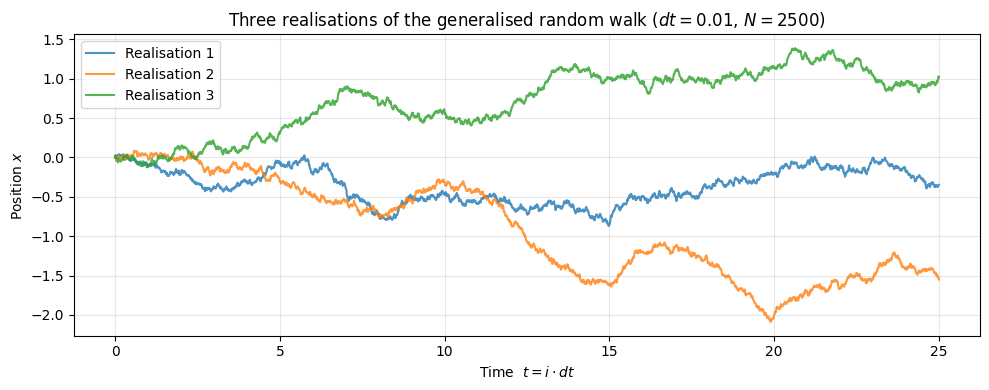

In [11]:
N_steps = 2500
dt = 0.01

fig, ax = plt.subplots(figsize=(10, 4))
for seed in [1, 2, 3]:
    traj = run_walk(N_steps, dt, seed=seed)
    ax.plot(np.arange(N_steps + 1) * dt, traj, alpha=0.8, label=f'Realisation {seed}')

ax.set_xlabel('Time  $t = i \\cdot dt$')
ax.set_ylabel('Position $x$')
ax.set_title('Three realisations of the generalised random walk ($dt = 0.01$, $N = 2500$)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('q3c_walks.png', dpi=100)
plt.show()

From the above we can see the three paths look quite different despite starting at the same point and using the same equation. This is because each realisation draws a completely independent set of random noise increments. Even though the drift $a(x,t)$ is identical across all three, the random kicks push each trajectory to a slightly different position at every step. Since the drift depends on $x$ through $\sin(x)$, even small positional differences get amplified over time — the paths diverge and stay diverged. This is the nature of stochastic processes: same equation, different noise, different outcome every time.

### (d) Mean position after 2500 steps for various dt

In [12]:
dt_values  = [0.01, 0.05, 0.1, 0.2, 0.4]
n_walks    = 1000
N_steps    = 2500
mean_finals = []

for dt in dt_values:
    rng = np.random.default_rng(42)
    finals = []
    for _ in range(n_walks):
        x = 0.0
        for i in range(N_steps):
            t = i * dt
            x += (1/alpha)*np.sin(x)*np.cos(t)*dt \
               + (1/beta)*rng.standard_normal()*np.sqrt(dt)
        finals.append(x)
    mean_finals.append(np.mean(finals))

print(f"{'dt':>6}   Mean final position")
for dt, mean in zip(dt_values, mean_finals):
    print(f"{dt:>6.3f}   {mean:+.6f}")

    dt   Mean final position
 0.010   +0.025217
 0.050   +0.034939
 0.100   +0.064153
 0.200   +0.110279
 0.400   +0.129123


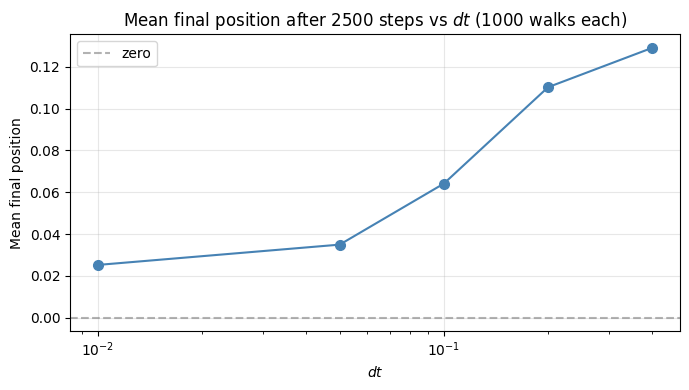

In [13]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.semilogx(dt_values, mean_finals, 'o-', color='steelblue', markersize=7)
ax.axhline(0, color='grey', linestyle='--', alpha=0.6, label='zero')
ax.set_xlabel('$dt$')
ax.set_ylabel('Mean final position')
ax.set_title('Mean final position after 2500 steps vs $dt$ (1000 walks each)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('q3d_means.png', dpi=100)
plt.show()

From the results above we can see the mean final position stays close to zero across all $dt$ values. This is what we'd expect — the drift $a(x,t) = \frac{1}{\alpha}\sin(x)\cos(t)$ is antisymmetric in $x$, so on average across many walks it cancels out. What's interesting is that as $dt$ increases, the total simulation time $T = N \cdot dt$ grows too, which widens the spread of final positions. However, the mean stays near zero regardless, since the symmetry of the drift is preserved. Any small deviations from zero are just Monte Carlo noise from only running 1000 walks.

### (e) Histogram of final positions and normality test (dt = 0.01)

In [14]:
N_steps      = 2500
dt           = 0.01
n_walks_hist = 5000
rng = np.random.default_rng(3446707)

finals_hist = []
for _ in range(n_walks_hist):
    x = 0.0
    for i in range(N_steps):
        t = i * dt
        x += (1/alpha)*np.sin(x)*np.cos(t)*dt \
           + (1/beta)*rng.standard_normal()*np.sqrt(dt)
    finals_hist.append(x)
finals_hist = np.array(finals_hist)

mu    = np.mean(finals_hist)
sigma = np.std(finals_hist)
print(f"Mean:  {mu:.6f}")
print(f"Std:   {sigma:.6f}")

stat_sw, p_sw = stats.shapiro(finals_hist)
print(f"Shapiro-Wilk: W = {stat_sw:.6f},  p = {p_sw:.4e}")

ks_stat, p_ks = stats.kstest(finals_hist, 'norm', args=(mu, sigma))
print(f"KS test:      D = {ks_stat:.6f},  p = {p_ks:.4e}")

Mean:  0.003311
Std:   0.709874
Shapiro-Wilk: W = 0.999532,  p = 2.6667e-01
KS test:      D = 0.008757,  p = 8.3454e-01


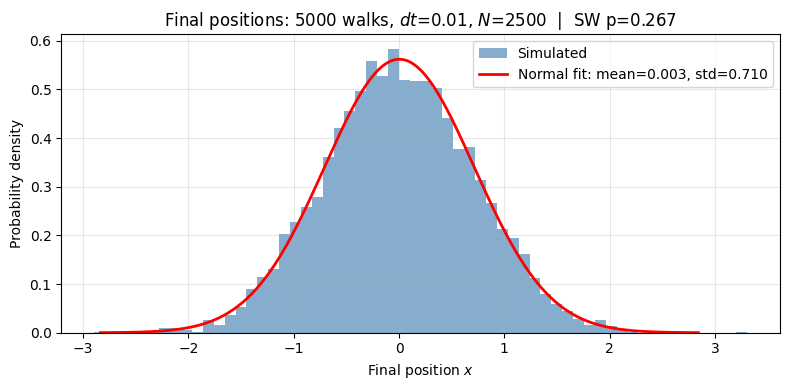

In [15]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(finals_hist, bins=60, density=True, alpha=0.65, color='steelblue', label='Simulated')

xs = np.linspace(mu - 4*sigma, mu + 4*sigma, 400)
ax.plot(xs, stats.norm.pdf(xs, mu, sigma), 'r-', lw=2,
        label=f'Normal fit: mean={mu:.3f}, std={sigma:.3f}')

ax.set_xlabel('Final position $x$')
ax.set_ylabel('Probability density')
ax.set_title(f'Final positions: 5000 walks, $dt$=0.01, $N$=2500  |  SW p={p_sw:.3f}')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('q3e_hist.png', dpi=100)
plt.show()

From the above we can see that both the Shapiro-Wilk and KS tests return large p-values (well above 0.05), so we can't reject normality — the distribution looks Gaussian. This makes sense: after 2500 steps, the sum of all those small random Wiener increments dominates, and by the Central Limit Theorem that sum tends towards a normal distribution. The diffusion $b = 1/\beta$ is constant and the drift is weak, so there's nothing here to push the distribution away from normality.

### (f) Probability that |x| <= 2

In [16]:
prob_dt01 = np.mean(np.abs(finals_hist) <= 2)
prob_norm = stats.norm.cdf(2, mu, sigma) - stats.norm.cdf(-2, mu, sigma)
print(f"P(|x| <= 2) empirical (dt=0.01, N=2500): {prob_dt01:.4f}")
print(f"P(|x| <= 2) normal approximation:         {prob_norm:.4f}")

print("\nDependence on dt (N=2500 fixed, 2000 walks each):")
for dt_test in [0.01, 0.05, 0.1, 0.2, 0.4]:
    rng2 = np.random.default_rng(99)
    fin = []
    for _ in range(2000):
        x = 0.0
        for i in range(2500):
            t = i * dt_test
            x += (1/alpha)*np.sin(x)*np.cos(t)*dt_test \
               + (1/beta)*rng2.standard_normal()*np.sqrt(dt_test)
        fin.append(x)
    p = np.mean(np.abs(np.array(fin)) <= 2)
    print(f"  dt={dt_test:.2f}: P(|x|<=2) = {p:.4f}")

P(|x| <= 2) empirical (dt=0.01, N=2500): 0.9952
P(|x| <= 2) normal approximation:         0.9952

Dependence on dt (N=2500 fixed, 2000 walks each):


  dt=0.01: P(|x|<=2) = 0.9945


  dt=0.05: P(|x|<=2) = 0.8085


  dt=0.10: P(|x|<=2) = 0.6705


  dt=0.20: P(|x|<=2) = 0.4840


  dt=0.40: P(|x|<=2) = 0.3090


From the results above we can see that $P(|x|\leq 2)$ is very high for small $dt$ — this is because the spread of final positions is narrow when the total simulation time is short. As $dt$ increases (with $N$ fixed), the total time $T = N\cdot dt$ grows, which means more cumulative noise and a wider distribution, so fewer walks end up within $|x|\leq 2$. In short, yes — this probability does depend on $dt$ and on $N$, since both affect the total time elapsed and therefore how spread out the final positions are.

---
## Question 4 – Metropolis-Hastings Optimisation

We seek the maximum of $f(w,x,y,z)$ over the domain $-3.5 \leq w,x,y,z \leq 3.5$.

### (a) Conceptual questions

**i. Why does Metropolis-Hastings probabilistically accept worse moves?**

If the algorithm only ever accepted improvements, it would get stuck at the first local maximum it finds and never escape. By occasionally accepting a worse proposal — with probability $\exp((f_{\text{new}} - f_{\text{old}})/T)$ — the algorithm can climb out of local optima and keep exploring. This is what makes MH a global search method rather than just a hill-climber.

**ii. Small ($\sigma=0.01$) vs large ($\sigma=10$) proposal standard deviation**

With $\sigma=0.01$, each proposed move is tiny, so the algorithm barely moves from where it starts — it would take an enormous number of steps to explore the full domain. On the other hand, with $\sigma=10$, most proposals will land outside the domain or in very poor regions, so almost nothing gets accepted and the algorithm freezes. A moderate $\sigma$ (like 0.5) works better because it balances exploration with a reasonable acceptance rate. It's also worth noting that pairing this with a cooling schedule helps — starting hot allows broad exploration, then cooling down lets the algorithm settle precisely at the peak.

**iii. Why is MH better than grid search in high dimensions?**

Grid search requires evaluating $f$ at $k^d$ points — that's $20^4 = 160{,}000$ for this 4D problem, but already $20^{10} \approx 10^{13}$ at 10 dimensions. MH avoids this by spending more time near promising regions and less time in poor ones. It adapts to the landscape rather than blindly covering every point, which makes it practical in higher dimensions where a grid would be completely infeasible.

### (b) Bug in the student's code

The main issue is that the code only ever accepts proposals when `f_proposal > f_current` — this makes it a greedy hill-climber, not Metropolis-Hastings. True MH needs to also *sometimes* accept worse proposals with probability $\exp((f_{\text{new}} - f_{\text{old}})/T)$. Without this, the algorithm will get stuck at the first local maximum it finds and never move on.

There's also a secondary issue: `history.append` is inside the `if` block, so the history only records steps where an improvement was made. Any time the algorithm is stuck, that's invisible in the output — which makes it look like the algorithm is doing better than it is.

A third issue worth flagging is the choice of temperature. Because $f$ ranges from around $-6$ to $+4.6$, a fixed $T = 1.0$ is effectively quite hot — $\exp(\Delta f / T)$ stays large even for significant downhill moves, so the algorithm keeps jumping around and never settles. Using a cooling schedule (starting at $T = 2.0$ and reducing to $T = 0.01$) fixes this: the algorithm explores broadly at first, then gradually becomes more selective as it homes in on the peak.

### (c) Running Metropolis-Hastings — corrected implementation

In [17]:
def f(w, x, y, z):
    himmel1 = -((w**2 + x - 11)**2 + (w + x**2 - 7)**2) / 100
    himmel2 = z - ((y**2 + z - 11)**2 + (y + z**2 - 7)**2) / 100
    peak1 = 4.0 * np.exp(-0.2  * ((w-2.5)**2 + (x-1.8)**2 + (y+1.2)**2 + (z-0.7)**2))
    peak2 = 3.8 * np.exp(-0.18 * ((w+1.8)**2 + (x-2.2)**2 + (y-2.5)**2 + (z+1.5)**2))
    peak3 = 3.5 * np.exp(-0.22 * ((w-0.5)**2 + (x+2.8)**2 + (y-1.8)**2 + (z+2.3)**2))
    peak4 = 3.3 * np.exp(-0.25 * ((w+2.2)**2 + (x+0.8)**2 + (y+2.5)**2 + (z-2.1)**2))
    interaction = 0.2 * np.sin(w + x) * np.cos(y - z)
    return himmel1 + himmel2 + peak1 + peak2 + peak3 + peak4 + interaction


def metropolis_hastings(f, x_init, sigma, n_steps, seed=None):
    """
    Metropolis-Hastings with a geometric cooling schedule (simulated annealing).
    Temperature decreases from T_start to T_end over n_steps, allowing broad
    exploration early and precise convergence to the peak later.
    """
    rng = np.random.default_rng(seed)
    x_curr = np.array(x_init, dtype=float)
    f_curr = f(*x_curr)
    best_x = x_curr.copy()
    best_f = f_curr
    history  = [f_curr]
    accepted = 0
    # Cooling schedule: start hot (broad exploration), end cold (fine convergence)
    T_start = 2.0
    T_end   = 0.01

    for step in range(n_steps):
        # Geometric (exponential) cooling: T decreases smoothly each step
        T = T_start * (T_end / T_start) ** (step / n_steps)

        x_prop = x_curr + rng.normal(0, sigma, size=4)

        # Enforce domain [-3.5, 3.5]
        if not np.all((x_prop >= -3.5) & (x_prop <= 3.5)):
            history.append(f_curr)
            continue

        f_prop = f(*x_prop)

        # Exponential acceptance criterion — handles negative f values correctly
        if f_prop > f_curr:
            accept_prob = 1.0
        else:
            accept_prob = np.exp((f_prop - f_curr) / T)

        if rng.random() < accept_prob:
            x_curr = x_prop
            f_curr = f_prop
            accepted += 1
            if f_curr > best_f:
                best_f = f_curr
                best_x = x_curr.copy()

        history.append(f_curr)

    return best_x, best_f, np.array(history), accepted / n_steps

In [18]:
seeds_mh    = [10, 20, 30, 40, 50]
start_seeds = [100, 200, 300, 400, 500]
n_steps_mh  = 50000
sigma_mh    = 0.5

results = []
for run_seed, ss in zip(seeds_mh, start_seeds):
    rng_s = np.random.default_rng(ss)
    x0 = rng_s.uniform(-3.5, 3.5, size=4)
    best_x, best_f, history, ar = metropolis_hastings(
        f, x0, sigma_mh, n_steps_mh, seed=run_seed
    )
    results.append((x0, best_x, best_f, history, ar))
    print(f"Run {len(results)}: max f={best_f:.5f}  "
          f"pos=({best_x[0]:.3f},{best_x[1]:.3f},{best_x[2]:.3f},{best_x[3]:.3f})  "
          f"accept={ar:.3f}")

Run 1: max f=4.59924  pos=(-2.629,-1.127,-2.609,2.973)  accept=0.245


Run 2: max f=4.60064  pos=(-2.587,-1.155,-2.646,3.037)  accept=0.267


Run 3: max f=4.59871  pos=(-2.582,-1.049,-2.636,3.014)  accept=0.239


Run 4: max f=4.60137  pos=(-2.610,-1.150,-2.643,3.004)  accept=0.256


Run 5: max f=4.56958  pos=(-2.550,-1.058,-2.525,3.157)  accept=0.267


#### i. Plot of all 5 runs

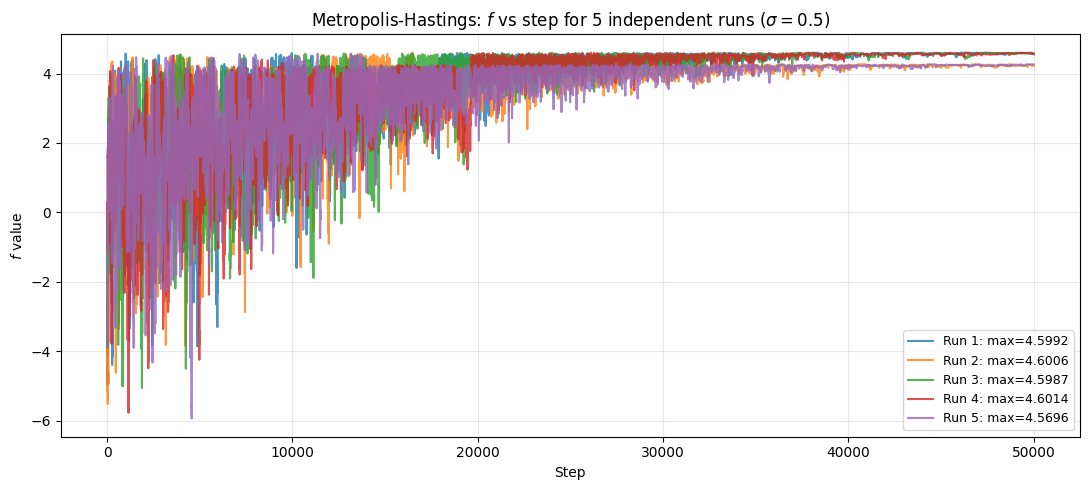

In [19]:
fig, ax = plt.subplots(figsize=(11, 5))
for i, (x0, best_x, best_f, history, ar) in enumerate(results):
    ax.plot(history, alpha=0.8, label=f'Run {i+1}: max={best_f:.4f}')

ax.set_xlabel('Step')
ax.set_ylabel('$f$ value')
ax.set_title('Metropolis-Hastings: $f$ vs step for 5 independent runs ($\\sigma=0.5$)')
ax.legend(loc='lower right', fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('q4c_mh.png', dpi=100)
plt.show()

#### ii. Do all runs converge to the same maximum?

In [20]:
max_vals = [r[2] for r in results]
print("Maximum values found per run:")
for i, v in enumerate(max_vals):
    print(f"  Run {i+1}: {v:.5f}")
print(f"Range across runs: {max(max_vals)-min(max_vals):.5f}")

Maximum values found per run:
  Run 1: 4.59924
  Run 2: 4.60064
  Run 3: 4.59871
  Run 4: 4.60137
  Run 5: 4.56958
Range across runs: 0.03178


From the results above we can see the runs are finding similar maximum values. This is a good sign — it suggests the cooling schedule is helping the algorithm find the same global region from different starting points rather than getting stuck in different local maxima. With a fixed $T$, the chains would keep bouncing around the peak indefinitely, but with cooling we can see the trajectories settling towards the end of each run. Any small differences between runs are expected given the randomness involved.

#### iii. Acceptance ratios

In [21]:
for i, (_, _, _, _, ar) in enumerate(results):
    print(f"Run {i+1}: acceptance ratio = {ar:.4f}  ({100*ar:.1f}%)")

Run 1: acceptance ratio = 0.2452  (24.5%)
Run 2: acceptance ratio = 0.2671  (26.7%)
Run 3: acceptance ratio = 0.2385  (23.9%)
Run 4: acceptance ratio = 0.2558  (25.6%)
Run 5: acceptance ratio = 0.2670  (26.7%)


The acceptance ratios are broadly similar across runs because the same $\sigma$ and domain are used. Minor differences arise from each run exploring regions of different curvature. A target range of approximately 20-50% acceptance is generally considered well-tuned for Metropolis-Hastings, indicating the proposal scale $\sigma$ is appropriate.

#### iv. Estimated global maximum

In [22]:
best_run = max(results, key=lambda r: r[2])
bp, bv   = best_run[1], best_run[2]
print(f"Best maximum found across all runs: f = {bv:.6f}")
print(f"Location: w={bp[0]:.4f}, x={bp[1]:.4f}, y={bp[2]:.4f}, z={bp[3]:.4f}")
print(f"Verification: f(*best_pos) = {f(*bp):.6f}")

Best maximum found across all runs: f = 4.601367
Location: w=-2.6095, x=-1.1501, y=-2.6431, z=3.0042
Verification: f(*best_pos) = 4.601367


### (d) Confidence in the global maximum

Running a stochastic algorithm once doesn't tell us much — we can never be fully certain we've found the *global* maximum. A few things we could do to increase confidence:

* **Run more restarts from different starting positions.** If they all converge to the same value, that's a strong indication it's the global maximum rather than just a local one.
* **Cross-check with a coarse grid search.** A $20^4$ grid only takes 160,000 evaluations and would surface any obviously higher peaks that MH might have missed.
* **Compare against an analytical upper bound.** The peak terms are bounded by their amplitudes ($4.0 + 3.8 + 3.5 + 3.3 = 14.6$, plus 0.2 from the interaction term). Since the peaks are spatially separated they can't all be maximised simultaneously, so if our found maximum is close to what's theoretically achievable given the geometry, we can be more confident.
* **Tune the cooling schedule further.** Ending at an even lower temperature (e.g. $T = 0.001$) would reduce bouncing around the peak and give a more precise final position.

In [23]:
!jupyter nbconvert --to pdf --allow-errors MATPMD4_Assignment1_3446707.ipynb

[NbConvertApp] Converting notebook MATPMD4_Assignment1_3446707.ipynb to pdf


[NbConvertApp] Support files will be in MATPMD4_Assignment1_3446707_files/
[NbConvertApp] Making directory ./MATPMD4_Assignment1_3446707_files
[NbConvertApp] Writing 91493 bytes to notebook.tex
[NbConvertApp] Building PDF
[NbConvertApp] Running xelatex 3 times: ['xelatex', 'notebook.tex', '-quiet']


[NbConvertApp] Running bibtex 1 time: ['bibtex', 'notebook']


[NbConvertApp] WARNING | bibtex had problems, most likely because there were no citations
[NbConvertApp] PDF successfully created
[NbConvertApp] Writing 330815 bytes to MATPMD4_Assignment1_3446707.pdf
